<a href="https://colab.research.google.com/github/kharsharaju/AIML_Assign_1/blob/main/Assignment_1_Harsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Task 1: Create Your Own Dataset**



In [1]:
import pandas as pd

data = {
    "Hours_Studied": [1,2,3,4,5,6,7,8,2,3,4,5,6,7,8],
    "Attendance": [60,65,70,75,80,85,90,95,68,72,78,82,88,91,96],
    "Exam_Score": [40,45,50,55,60,65,70,75,48,52,58,63,68,72,78]
}

df = pd.DataFrame(data)

print(df)

    Hours_Studied  Attendance  Exam_Score
0               1          60          40
1               2          65          45
2               3          70          50
3               4          75          55
4               5          80          60
5               6          85          65
6               7          90          70
7               8          95          75
8               2          68          48
9               3          72          52
10              4          78          58
11              5          82          63
12              6          88          68
13              7          91          72
14              8          96          78


**Task 2: Data Exploration**

In [2]:
print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nDataset Shape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

First 5 Rows
   Hours_Studied  Attendance  Exam_Score
0              1          60          40
1              2          65          45
2              3          70          50
3              4          75          55
4              5          80          60

Last 5 Rows
    Hours_Studied  Attendance  Exam_Score
10              4          78          58
11              5          82          63
12              6          88          68
13              7          91          72
14              8          96          78

Dataset Shape
(15, 3)

Data Types
Hours_Studied    int64
Attendance       int64
Exam_Score       int64
dtype: object

Missing Values
Hours_Studied    0
Attendance       0
Exam_Score       0
dtype: int64


**Task 3: Data Visualization**

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


Scatter Plot

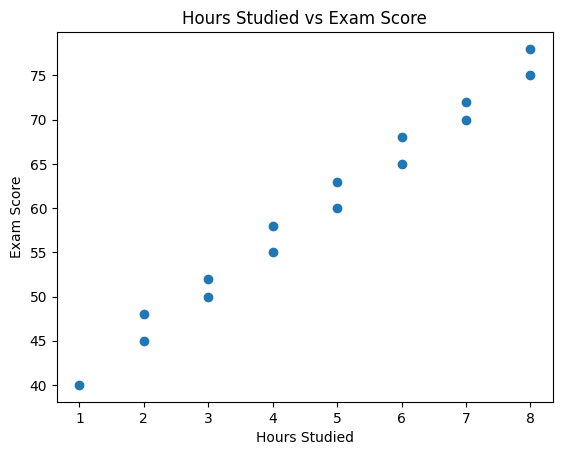

In [4]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()


Histogram

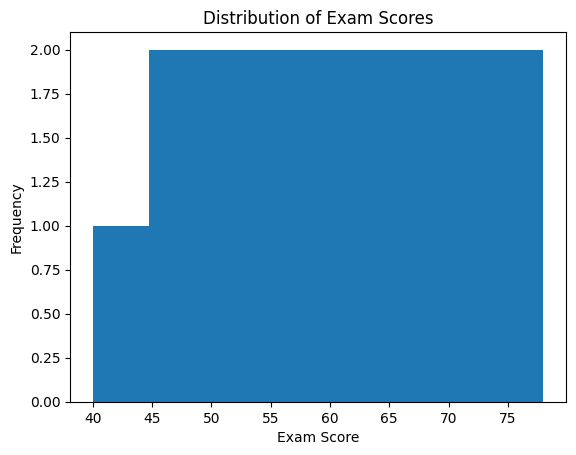

In [5]:
plt.hist(df["Exam_Score"], bins=8)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

Boxplot

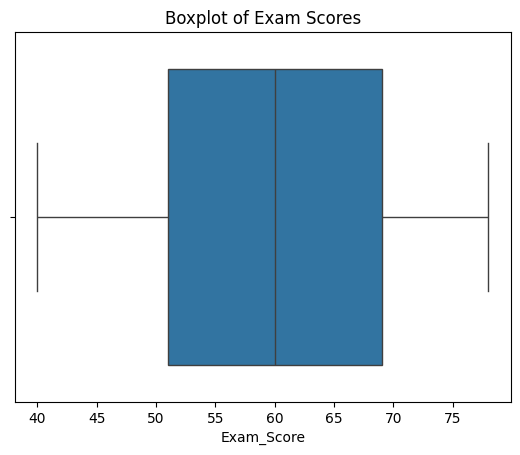

In [6]:
sns.boxplot(x=df["Exam_Score"])
plt.title("Boxplot of Exam Scores")
plt.show()

**Task 4: Train Linear Regression Model**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Split Dataset

In [8]:
X = df[["Hours_Studied", "Attendance"]]
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Dataset

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

Evaluation

In [10]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.3875147232037695
R2 Score: 0.9973678684227022


**Task 5: Feature Experiment**

Remove one feature - attendence

In [11]:
X = df[["Hours_Studied"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 without Attendance:", r2_score(y_test, pred))

R2 without Attendance: 0.8818737984128742


Add New feature

In [12]:
df["Study_Efficiency"] = df["Hours_Studied"] * df["Attendance"] / 100

X = df[["Hours_Studied", "Attendance", "Study_Efficiency"]]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 with new feature:", r2_score(y_test, pred))

R2 with new feature: 0.9689912399279903


**Task 6: Overfitting Check**

In [14]:
X = df[["Hours_Studied", "Attendance"]]
y = df["Exam_Score"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

print("R2 without split:", r2_score(y, pred))

R2 without split: 0.9980196026846289
